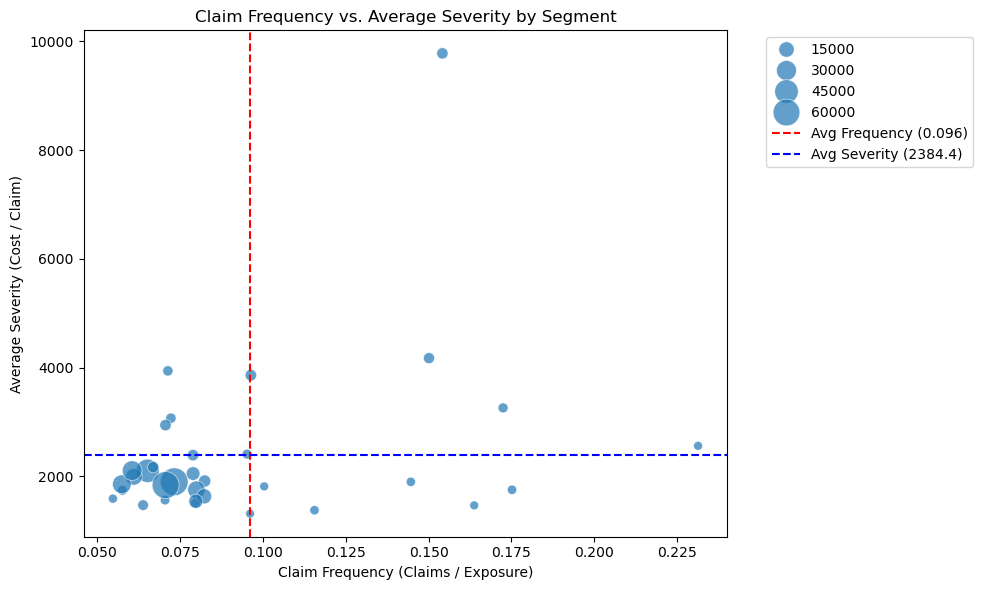

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_freq = pd.read_csv("../../data/freMTPL2freq.csv")
df_sev = pd.read_csv("../../data/df_sev_clean.csv")

# ۱. ادغام داده‌ها
claims_per_policy = df_sev.groupby('IDpol')['ClaimAmount'].sum().reset_index()
df_merged = pd.merge(df_freq, claims_per_policy, on='IDpol', how='left')
df_merged['ClaimAmount'] = df_merged['ClaimAmount'].fillna(0)

# ۲. ایجاد بخش‌ها (مثلاً ترکیب سن راننده و برند خودرو)
df_merged['Segment'] = df_merged['VehBrand'] + "_" + pd.cut(df_merged['DrivAge'], bins=[17, 25, 55, 100], labels=['Young', 'Adult', 'Senior']).astype(str)

# ۳. محاسبه Frequency و Severity برای هر بخش
segment_analysis = df_merged.groupby('Segment').agg(
    Total_Exposure=('Exposure', 'sum'),
    Total_Claims=('ClaimNb', 'sum'),
    Total_Cost=('ClaimAmount', 'sum')
).reset_index()

# حذف بخش‌های بدون خسارت برای جلوگیری از تقسیم بر صفر
segment_analysis = segment_analysis[segment_analysis['Total_Claims'] > 0]

segment_analysis['Frequency'] = segment_analysis['Total_Claims'] / segment_analysis['Total_Exposure']
segment_analysis['Severity'] = segment_analysis['Total_Cost'] / segment_analysis['Total_Claims']

# ۴. رسم نمودار Scatter Plot با Quadrants
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=segment_analysis, 
    x='Frequency', 
    y='Severity', 
    size='Total_Exposure', 
    sizes=(40, 400), 
    alpha=0.7
)

# -------
# محور X نشان‌دهنده‌ی Frequency است.
# هرچه نقطه به سمت راست‌تر باشد، فراوانی خسارت آن Segment بیشتر است.
# 
# محور Y نشان‌دهنده‌ی Severity است.
# هرچه نقطه بالاتر باشد، میانگین هزینه‌ی هر خسارت بیشتر است.
# -------

# میانگین‌ها برای تقسیم‌بندی ۴ ناحیه (Quadrants)
avg_freq = segment_analysis['Frequency'].mean()
avg_sev = segment_analysis['Severity'].mean()

plt.axvline(avg_freq, color='red', linestyle='--', label=f'Avg Frequency ({avg_freq:.3f})')
plt.axhline(avg_sev, color='blue', linestyle='--', label=f'Avg Severity ({avg_sev:.1f})')

plt.title('Claim Frequency vs. Average Severity by Segment')
plt.xlabel('Claim Frequency (Claims / Exposure)')
plt.ylabel('Average Severity (Cost / Claim)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()